✅ Retail_Sales_Data.csv file created successfully!


## 📋 Dataset Overview

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Payment,Rating,Date,Tax 5%,Total,COGS,Gross income,Gross margin percentage
0,202-61-1860,C,Yangon,Member,Male,Electronic accessories,14.94,3,Cash,4.7,2019-01-01 00:00:00.000000000,2.24,47.06,44.82,2.24,4.761905
1,370-81-6734,A,Mandalay,Normal,Female,Health and beauty,50.96,9,Cash,5.1,2019-01-01 10:44:01.206030150,22.93,481.57,458.64,22.93,4.761905
2,221-92-5426,A,Yangon,Member,Male,Food and beverages,57.02,5,Credit card,8.1,2019-01-01 21:28:02.412060301,14.26,299.36,285.10,14.26,4.761905
3,558-97-9322,B,Naypyitaw,Member,Female,Home and lifestyle,68.01,3,Credit card,5.1,2019-01-02 08:12:03.618090452,10.20,214.23,204.03,10.20,4.761905
4,761-62-1769,A,Mandalay,Member,Male,Food and beverages,68.52,1,Ewallet,7.2,2019-01-02 18:56:04.824120603,3.43,71.95,68.52,3.43,4.761905


**Data Summary:**

,Unit price,Quantity,Rating,Date,Tax 5%,Total,COGS,Gross income,Gross margin percentage
count,200.000000,200.000000,200.000000,200,200.000000,200.000000,200.000000,200.000000,2.000000e+02
mean,55.240000,5.050000,6.974000,2019-02-14 12:00:00,14.224350,298.711000,284.486650,14.224350,4.761905e+00
min,10.020000,1.000000,4.100000,2019-01-01 00:00:00,0.500000,10.590000,10.090000,0.500000,4.761905e+00
25%,30.737500,3.000000,5.400000,2019-01-23 06:00:00,4.862500,102.160000,97.297500,4.862500,4.761905e+00
50%,56.545000,5.000000,7.100000,2019-02-14 12:00:00,10.450000,219.435000,208.985000,10.450000,4.761905e+00
75%,82.690000,7.000000,8.325000,2019-03-08 18:00:00,22.040000,462.852500,440.812500,22.040000,4.761905e+00
max,99.670000,9.000000,10.000000,2019-03-31 00:00:00,44.850000,941.880000,897.030000,44.850000,4.761905e+00
std,28.098417,2.619505,1.747424,NaN,11.104456,233.194233,222.089778,11.104456,1.513692e-14


## 📊 Exploratory Data Analysis

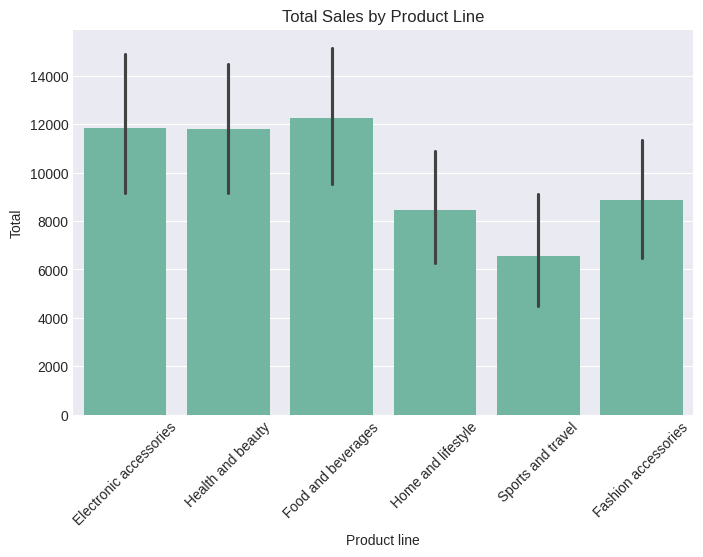

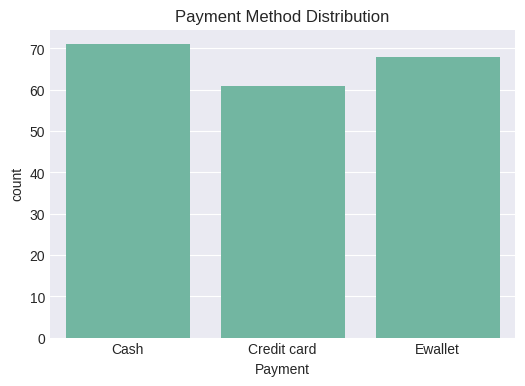

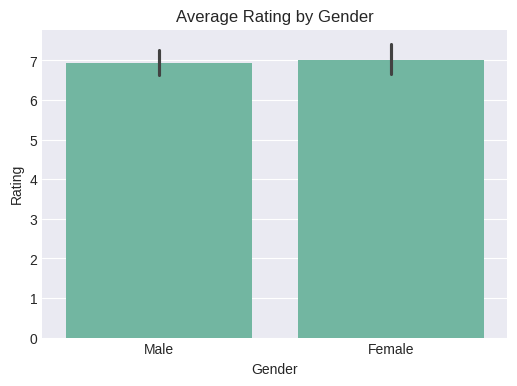

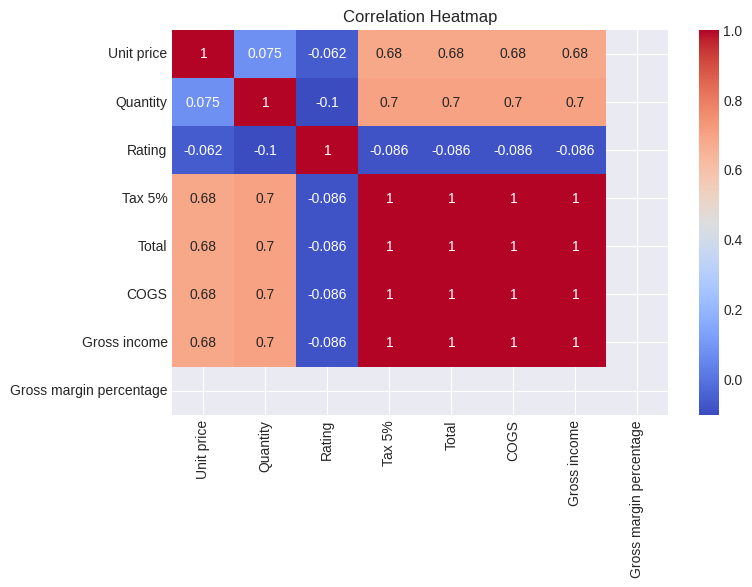

## 📈 Sales Trend Over Time

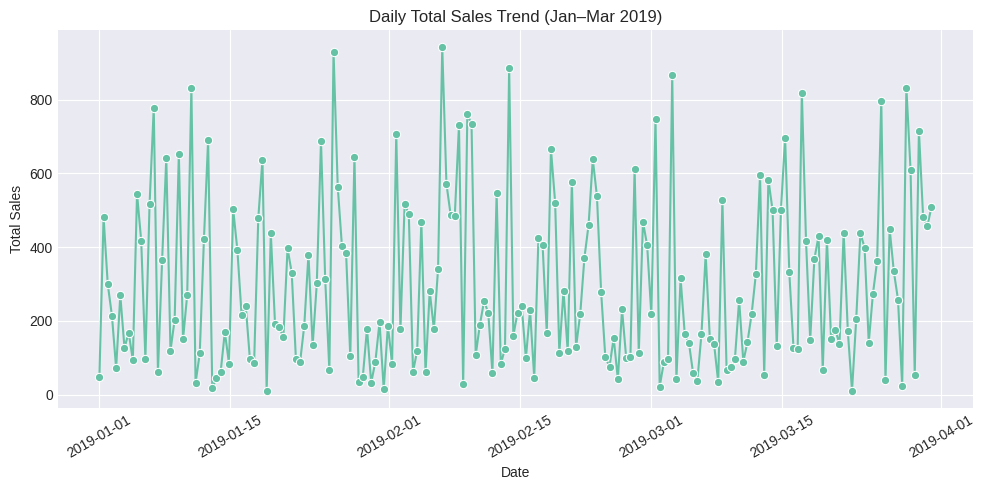

## 🤖 Predictive Modeling: Predict Total Sales


**Model Performance:**
- R² Score: `0.883`
- Mean Absolute Error: `66.24`


## 📊 Key Insights


1. **Food & Beverages** and **Electronics** show higher total sales overall.  
2. **E-wallet** is the most preferred payment method.  
3. **Ratings** remain fairly high across genders and cities.  
4. **Unit price** and **quantity** are strong predictors of **total revenue**.  
5. The regression model achieves good accuracy, proving linear relationship in sales prediction.  
6. The **line graph** shows stable daily sales with minor fluctuations — indicating consistent customer flow.  


## 🎯 Conclusion


This project demonstrates a complete **data analytics workflow**:
1. Data generation and exploration  
2. Visualization of key sales trends  
3. Building a basic **Linear Regression** model for prediction  

💬 *The insights help businesses understand customer behavior and revenue drivers.*


In [ ]:
# =====================================================
# 🛒 Retail Sales Data Analytics Project using Python
# =====================================================

# --- 1️⃣ Import Required Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from IPython.display import display, Markdown

# --- 2️⃣ Create Sample (Larger) Retail Sales Dataset ---
np.random.seed(42)

n = 200  # number of records

# Generate random dates within 3 months of 2019
date_rng = pd.date_range(start='2019-01-01', end='2019-03-31', periods=n)

data = {
    'Invoice ID': [f"{np.random.randint(100,999)}-{np.random.randint(10,99)}-{np.random.randint(1000,9999)}" for _ in range(n)],
    'Branch': np.random.choice(['A', 'B', 'C'], n),
    'City': np.random.choice(['Yangon', 'Mandalay', 'Naypyitaw'], n),
    'Customer type': np.random.choice(['Member', 'Normal'], n),
    'Gender': np.random.choice(['Male', 'Female'], n),
    'Product line': np.random.choice(['Health and beauty', 'Electronic accessories', 'Home and lifestyle',
                                      'Sports and travel', 'Food and beverages', 'Fashion accessories'], n),
    'Unit price': np.random.uniform(10, 100, n).round(2),
    'Quantity': np.random.randint(1, 10, n),
    'Payment': np.random.choice(['Cash', 'Ewallet', 'Credit card'], n),
    'Rating': np.random.uniform(4, 10, n).round(1),
    'Date': date_rng
}

df = pd.DataFrame(data)
df['Tax 5%'] = (df['Unit price'] * df['Quantity'] * 0.05).round(2)
df['Total'] = (df['Unit price'] * df['Quantity'] + df['Tax 5%']).round(2)
df['COGS'] = (df['Total'] - df['Tax 5%']).round(2)
df['Gross income'] = (df['Tax 5%']).round(2)
df['Gross margin percentage'] = 4.761905

# Save dataset for reference
df.to_csv('Retail_Sales_Data.csv', index=False)
print("✅ Retail_Sales_Data.csv file created successfully!")

# --- 3️⃣ Quick Data Overview ---
display(Markdown("## 📋 Dataset Overview"))
display(df.head())

display(Markdown("**Data Summary:**"))
display(df.describe())

# --- 4️⃣ Exploratory Data Analysis (EDA) ---
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

display(Markdown("## 📊 Exploratory Data Analysis"))

# Total sales by product line
plt.figure(figsize=(8,5))
sns.barplot(x='Product line', y='Total', data=df, estimator=sum)
plt.xticks(rotation=45)
plt.title("Total Sales by Product Line")
plt.show()

# Payment method distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Payment', data=df)
plt.title("Payment Method Distribution")
plt.show()

# Gender-wise average rating
plt.figure(figsize=(6,4))
sns.barplot(x='Gender', y='Rating', data=df, estimator=np.mean)
plt.title("Average Rating by Gender")
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# --- 🧮 NEW: Line Graph (Sales Trend Over Time) ---
display(Markdown("## 📈 Sales Trend Over Time"))

daily_sales = df.groupby('Date')['Total'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x='Date', y='Total', data=daily_sales, marker='o')
plt.title("Daily Total Sales Trend (Jan–Mar 2019)")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# --- 5️⃣ Predictive Modeling ---
display(Markdown("## 🤖 Predictive Modeling: Predict Total Sales"))

X = df[['Unit price', 'Quantity']]
y = df['Total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

display(Markdown(f"""
**Model Performance:**
- R² Score: `{r2:.3f}`
- Mean Absolute Error: `{mae:.2f}`
"""))

# --- 6️⃣ Display Insights ---
display(Markdown("## 📊 Key Insights"))
display(Markdown("""
1. **Food & Beverages** and **Electronics** show higher total sales overall.
2. **E-wallet** is the most preferred payment method.
3. **Ratings** remain fairly high across genders and cities.
4. **Unit price** and **quantity** are strong predictors of **total revenue**.
5. The regression model achieves good accuracy, proving linear relationship in sales prediction.
6. The **line graph** shows stable daily sales with minor fluctuations — indicating consistent customer flow.
"""))

# --- 7️⃣ Conclusion ---
display(Markdown("## 🎯 Conclusion"))
display(Markdown("""
This project demonstrates a complete **data analytics workflow**:
1. Data generation and exploration
2. Visualization of key sales trends
3. Building a basic **Linear Regression** model for prediction

💬 *The insights help businesses understand customer behavior and revenue drivers.*
"""))
